# Libraries and Setup

In [35]:
try:
    import qiskit
except ImportError:
    !pip install -U qiskit
    !pip install -U qiskit-ibm-runtime
    !pip install -U pylatexenc
    !pip install -U qiskit-aer
    !pip install -U qiskit-algorithms


In [36]:
import matplotlib
import matplotlib.pyplot as plt
import rustworkx as rx
import networkx as nx
from rustworkx.visualization import mpl_draw as draw_graph
import numpy as np
from scipy.optimize import minimize
from collections import defaultdict
from typing import Sequence

from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit.library import QAOAAnsatz
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager


from qiskit_aer import AerSimulator
from qiskit.primitives import StatevectorEstimator
from qiskit.primitives import StatevectorSampler
from qiskit.primitives import BackendEstimatorV2, BackendSamplerV2

from qiskit_algorithms.optimizers import L_BFGS_B

from functools import partial
import itertools

In [37]:
backend = AerSimulator(
    method='matrix_product_state',
    mps_log_data=True,
    shots=1024
)

estimator = BackendEstimatorV2(backend=backend,
    options={
        "default_precision": 0.015625,
        "abelian_grouping": True,
        "seed_simulator": 42
    })

sampler = BackendSamplerV2(backend=backend)

# Helper Functions

In [38]:
def cost_func_estimator(params, ansatz, hamiltonian, estimator, objective_func_vals_list):
    isa_hamiltonian = hamiltonian.apply_layout(ansatz.layout)

    pub = (ansatz, isa_hamiltonian, params)
    job = estimator.run([pub])

    results = job.result()[0]
    cost = -results.data.evs

    objective_func_vals_list.append(cost)

    return cost

In [39]:
def to_bitstring(integer, num_bits):
    result = np.binary_repr(integer, width=num_bits)
    return [int(digit) for digit in result]

In [40]:
def plot_result(G, x):
    colors = ["tab:grey" if i == 0 else "tab:purple" for i in x]
    pos, _default_axes = rx.spring_layout(G), plt.axes(frameon=True)
    rx.visualization.mpl_draw(
        G, node_color=colors, node_size=100, alpha=0.8, pos=pos
    )

In [41]:
def evaluate_sample(x: Sequence[int], graph: rx.PyGraph) -> float:
    return sum(
        graph.get_edge_data(u, v) * (x[u] * (1 - x[v]) + x[v] * (1 - x[u]))
        for u, v in list(graph.edge_list())
    )

In [42]:
_PARITY = np.array(
    [-1 if bin(i).count("1") % 2 else 1 for i in range(256)],
    dtype=np.complex128,
)

def evaluate_sparse_pauli(state: int, observable: SparsePauliOp) -> complex:
    packed_uint8 = np.packbits(observable.paulis.z, axis=1, bitorder="little")
    state_bytes = np.frombuffer(
        state.to_bytes(packed_uint8.shape[1], "little"), dtype=np.uint8
    )
    reduced = np.bitwise_xor.reduce(packed_uint8 & state_bytes, axis=1)
    return np.sum(observable.coeffs * _PARITY[reduced])


def best_solution(samples, hamiltonian):
    min_cost = 1000
    min_sol = None
    for bit_str in samples.keys():
        candidate_sol = int(bit_str)
        fval = evaluate_sparse_pauli(candidate_sol, hamiltonian).real
        if fval <= min_cost:
            min_cost = fval
            min_sol = candidate_sol

    return min_sol

In [43]:
def _plot_cdf(objective_values: dict, ax, color):
    x_vals = sorted(objective_values.keys(), reverse=True)
    y_vals = np.cumsum([objective_values[x] for x in x_vals])
    ax.plot(x_vals, y_vals, color=color)

def plot_cdf(dist, ax, title):
    _plot_cdf(
        dist,
        ax,
        "C1",
    )
    ax.vlines(min(list(dist.keys())), 0, 1, "C1", linestyle="--")

    ax.set_title(title)
    ax.set_xlabel("Objective function value")
    ax.set_ylabel("Cumulative distribution function")
    ax.grid(alpha=0.3)

def samples_to_objective_values(samples, hamiltonian):
    objective_values = defaultdict(float)
    for bit_str, prob in samples.items():
        candidate_sol = int(bit_str)
        fval = evaluate_sparse_pauli(candidate_sol, hamiltonian).real
        objective_values[fval] += prob

    return objective_values

In [44]:
def evaluate_sample(x: Sequence[int], graph: rx.PyGraph) -> float:
    return sum(
        graph.get_edge_data(u, v) * (x[u] * (1 - x[v]) + x[v] * (1 - x[u]))
        for u, v in list(graph.edge_list())
    )

In [45]:
def build_max_cut_paulis(graph: rx.PyGraph) -> list[tuple[str, float]]:
    pauli_list = []
    for edge in list(graph.edge_list()):
        weight = graph.get_edge_data(edge[0], edge[1])
        pauli_list.append(("ZZ", [edge[0], edge[1]], weight))
    return pauli_list

# QGOA

In [46]:
from qiskit.circuit.library import PauliEvolutionGate
from qiskit.synthesis import LieTrotter

def build_qgoa_circuit(graph, reps: int = 1):
    num_qubits = len(graph.nodes())
    circuit = QuantumCircuit(num_qubits)
    circuit.h(range(num_qubits))

    for layer in range(reps):
        for qubit in range(num_qubits):
            theta_y = Parameter(f"theta_y_{layer}_{qubit}")
            theta_z = Parameter(f"theta_z_{layer}_{qubit}")
            circuit.ry(theta_y, qubit)
            circuit.rz(theta_z, qubit)

        eta = Parameter(f"eta_{layer}")
        pauli_list_xx = []
        pauli_list_yy = []

        for edge in graph.edge_list():
            u, v = edge
            weight = graph.get_edge_data(u, v)
            pauli_list_xx.append(("XX", [u, v], weight))
            pauli_list_yy.append(("YY", [u, v], weight))

        pauli_list = pauli_list_xx + pauli_list_yy

        hamiltonian = SparsePauliOp.from_sparse_list(pauli_list, num_qubits=num_qubits)

        synthesis = LieTrotter(reps=2)
        evol_gate = PauliEvolutionGate(hamiltonian, time=eta, synthesis=synthesis)
        circuit.append(evol_gate, range(num_qubits))

    return circuit

In [47]:
from qiskit_algorithms.optimizers import L_BFGS_B
from functools import partial

def run_qgoa(graph, num_layers):
  max_cut_paulis = build_max_cut_paulis(graph)

  cost_hamiltonian = SparsePauliOp.from_sparse_list(max_cut_paulis, len(graph))

  circuit = build_qgoa_circuit(graph, reps=num_layers)

  pm = generate_preset_pass_manager(optimization_level=3)

  candidate_circuit = pm.run(circuit)

  num_qubits = len(graph)

  init_params = []
  for param in circuit.parameters:
      if param.name.startswith('eta'):
          init_params.append(np.random.uniform(-0.01, 0.01))
      else:
          init_params.append(np.random.uniform(0, 2 * np.pi))

  objective_func_vals = []

  optimizer = L_BFGS_B(maxiter=100)

  bound_cost_func = partial(cost_func_estimator,
                            ansatz=candidate_circuit,
                            hamiltonian=cost_hamiltonian,
                            estimator=estimator,
                            objective_func_vals_list=objective_func_vals)

  result = optimizer.minimize(
      fun=bound_cost_func,
      x0=init_params
  )

  optimized_circuit = candidate_circuit.assign_parameters(result.x)
  optimized_circuit.measure_all()

  pub = (optimized_circuit,)
  job = sampler.run([pub])

  result = job.result()[0]
  counts_bin = result.data.meas.get_counts()

  counts_int = {int(k, 2): v for k, v in counts_bin.items()}
  shots = sum(counts_int.values())
  final_distribution_int = {
      key: val / shots for key, val in counts_int.items()
  }

  best_sol = best_solution(final_distribution_int, cost_hamiltonian)
  best_sol_bitstring = to_bitstring(int(best_sol), len(graph))
  best_sol_bitstring.reverse()

  cut_value = evaluate_sample(best_sol_bitstring, graph)

  result_dist = samples_to_objective_values(
    final_distribution_int, cost_hamiltonian
  )

  return cut_value, best_sol_bitstring, objective_func_vals

In [48]:
def qgoa_average_approximation_ratio(graphs, num_layers = 1):

  approximation_ratios = {}
  all_objective_func_vals = {}

  for graph_tuple in graphs:
    print(f"Calculating graph {graph_tuple['type']} (N={graph_tuple['n_nodes']}) with {num_layers} layers using QGOA")
    graph = graph_tuple['graph']
    qgoa_cut_val, _, obj_vals = run_qgoa(graph, num_layers)
    actual_cut_value, _ = bruteforce_max_cut(graph)

    if actual_cut_value != 0:
        ar = qgoa_cut_val / actual_cut_value
    else:
        ar = 0.0

    approximation_ratios[(graph_tuple['type'], graph_tuple['n_nodes'])] = ar
    all_objective_func_vals[(graph_tuple['type'], graph_tuple['n_nodes'])] = obj_vals
    print(f"QGOA: {qgoa_cut_val}, Actual: {actual_cut_value}, AR: {ar}")

  return approximation_ratios, all_objective_func_vals

# QAOA

In [49]:
def build_qaoa_circuit(cost_hamiltonian, reps=1):
    num_qubits = cost_hamiltonian.num_qubits

    gamma_params = [Parameter(f"γ_{i}") for i in range(reps)]
    beta_params = [Parameter(f"β_{i}") for i in range(reps)]

    circuit = QuantumCircuit(num_qubits)

    circuit.h(range(num_qubits))

    for rep in range(reps):
        pauli_list = cost_hamiltonian.to_list()

        for pauli, coeff in pauli_list:
            if 'ZZ' in pauli:
                indices = [i for i, p in enumerate(pauli[::-1]) if p == 'Z']
                if len(indices) == 2:
                    i, j = indices
                    circuit.rzz(2 * coeff * gamma_params[rep], i, j)

        for i in range(num_qubits):
            circuit.rx(2 * beta_params[rep], i)

    return circuit

In [50]:
def run_qaoa(graph, num_layers):
  max_cut_paulis = build_max_cut_paulis(graph)

  cost_hamiltonian = SparsePauliOp.from_sparse_list(max_cut_paulis, len(graph))

  circuit = build_qaoa_circuit(cost_hamiltonian, reps=num_layers)

  pm = generate_preset_pass_manager(optimization_level=3)

  candidate_circuit = pm.run(circuit)

  initial_gamma = np.pi
  initial_beta = np.pi/4
  init_params = []
  for rep in range(num_layers):
      init_params.append(initial_gamma)
      init_params.append(initial_beta)

  objective_func_vals = []

  optimizer = L_BFGS_B(maxiter=100)

  bound_cost_func = partial(cost_func_estimator,
                            ansatz=candidate_circuit,
                            hamiltonian=cost_hamiltonian,
                            estimator=estimator,
                            objective_func_vals_list=objective_func_vals)

  result = optimizer.minimize(
      fun=bound_cost_func,
      x0=init_params
  )

  optimized_circuit = candidate_circuit.assign_parameters(result.x)
  optimized_circuit.measure_all()

  pub = (optimized_circuit,)
  job = sampler.run([pub])

  result = job.result()[0]
  counts_bin = result.data.meas.get_counts()

  counts_int = {int(k, 2): v for k, v in counts_bin.items()}
  shots = sum(counts_int.values())
  final_distribution_int = {
      key: val / shots for key, val in counts_int.items()
  }

  best_sol = best_solution(final_distribution_int, cost_hamiltonian)
  best_sol_bitstring = to_bitstring(int(best_sol), len(graph))
  best_sol_bitstring.reverse()

  cut_value = evaluate_sample(best_sol_bitstring, graph)

  result_dist = samples_to_objective_values(
    final_distribution_int, cost_hamiltonian
  )

  return cut_value, best_sol_bitstring, objective_func_vals

In [51]:
def qaoa_average_approximation_ratio(graphs, num_layers = 3):

  approximation_ratios = {}
  all_objective_func_vals = {}
  for graph_tuple in graphs:
    print(f"Calculating graph {graph_tuple['type']} (N={graph_tuple['n_nodes']}) with {num_layers} layers using QAOA")
    graph = graph_tuple['graph']
    qaoa_cut_val, _, obj_vals = run_qaoa(graph, num_layers)
    actual_cut_value, _ = bruteforce_max_cut(graph)

    if actual_cut_value != 0:
        ar = qaoa_cut_val / actual_cut_value
    else:
        ar = 0.0

    approximation_ratios[(graph_tuple['type'], graph_tuple['n_nodes'])] = ar
    all_objective_func_vals[(graph_tuple['type'], graph_tuple['n_nodes'])] = obj_vals
    print(f"QAOA: {qaoa_cut_val}, Actual: {actual_cut_value}, AR: {ar}")
  return approximation_ratios, all_objective_func_vals

# Classic methods



## Brute-Force Solution

In [52]:
import itertools

def bruteforce_max_cut(graph: rx.PyGraph, max_nodes_limit: int = 20):
    num_nodes = graph.num_nodes()

    if num_nodes > max_nodes_limit:
        print(f"Число вершин {num_nodes} превышает допустимый предел\n")
        return None, None

    best_cut_value = float('-inf')
    best_partition = None

    for partition_tuple in itertools.product([0, 1], repeat=num_nodes):
        current_partition = list(partition_tuple)
        current_cut_value = evaluate_sample(current_partition, graph)

        if current_cut_value > best_cut_value:
            best_cut_value = current_cut_value
            best_partition = current_partition

    return best_cut_value, best_partition

## Greedy solution

In [53]:
def greedy_max_cut(graph):
    num_nodes = graph.num_nodes()
    if num_nodes == 0:
        return 0.0, []

    partition = [np.random.randint(0, 2) for _ in range(num_nodes)]
    current_cut_value = evaluate_sample(partition, graph)

    improved = True
    while improved:
        improved = False
        for i in range(num_nodes):
            original_partition_i = partition[i]
            partition[i] = 1 - partition[i]
            new_cut_value = evaluate_sample(partition, graph)

            if new_cut_value > current_cut_value:
                current_cut_value = new_cut_value
                improved = True
            else:
                partition[i] = original_partition_i

    return current_cut_value, partition

# Experiment

## Graph Generation

In [54]:
import rustworkx as rx
import networkx as nx
import numpy as np

def generate_3_regular_graph_sample(num_nodes: int) -> rx.PyGraph:
    if num_nodes % 2 != 0:
        raise ValueError("3-regular graph requires an even number of vertices.")
    if num_nodes < 4:
        raise ValueError("3-regular graph must have at least 4 nodes.")

    nx_graph = nx.random_regular_graph(3, num_nodes, seed=None)

    graph = rx.PyGraph()
    node_indices = [graph.add_node(idx) for idx in range(num_nodes)]
    for u, v in nx_graph.edges():
        random_weight = np.random.uniform(0, 1)
        graph.add_edge(node_indices[u], node_indices[v], random_weight)
    return graph

In [55]:
def get_grid_dimensions(num_nodes: int):
    best_rows = 1
    best_cols = num_nodes
    for i in range(1, int(np.sqrt(num_nodes)) + 1):
        if num_nodes % i == 0:
            best_rows = i
            best_cols = num_nodes // i
    return best_rows, best_cols

def generate_graph(graph_type: str, num_nodes: int) -> rx.PyGraph:
    graph = rx.PyGraph()

    if graph_type == 'complete':
        graph.add_nodes_from(range(num_nodes))
        for i in range(num_nodes):
            for j in range(i + 1, num_nodes):
                random_weight = np.random.uniform(0, 1)
                graph.add_edge(i, j, random_weight)
    elif graph_type == 'cycle':
        graph.add_nodes_from(range(num_nodes))
        for i in range(num_nodes):
            random_weight = np.random.uniform(0, 1)
            graph.add_edge(i, (i + 1) % num_nodes, random_weight)
    elif graph_type == 'grid':
        rows, cols = get_grid_dimensions(num_nodes)
        if rows == 0 or cols == 0:
            raise ValueError(f"Invalid grid dimensions for {num_nodes} nodes: rows={rows}, cols={cols}")
        graph = rx.generators.grid_graph(rows, cols)
        processed_edges = set()
        for u_node in graph.node_indices():
            for v_node in graph.neighbors(u_node):
                if (u_node, v_node) not in processed_edges and (v_node, u_node) not in processed_edges:
                    random_weight = np.random.uniform(0, 1)
                    graph.update_edge(u_node, v_node, random_weight)
                    processed_edges.add((u_node,v_node))
    elif graph_type == 'petersen':
        if num_nodes != 10:
            raise ValueError(f"Petersen graph has a fixed number of 10 nodes, but {num_nodes} was requested.")
        graph = rx.generators.generalized_petersen_graph(5, 2)
        processed_edges = set()
        for u_node in graph.node_indices():
            for v_node in graph.neighbors(u_node):
                if (u_node, v_node) not in processed_edges and (v_node, u_node) not in processed_edges:
                    random_weight = np.random.uniform(0, 1)
                    graph.update_edge(u_node, v_node, random_weight)
                    processed_edges.add((u_node,v_node))
    else:
        raise ValueError(f"Unsupported graph type: {graph_type}. Choose from 'complete', 'cycle', 'grid', or 'petersen'.")

    return graph

all_generated_graphs = []
graph_types = ['complete', 'cycle', 'grid', 'petersen']

for n_nodes in range(4, 15):
    for g_type in graph_types:
        try:
            if g_type == 'petersen' and n_nodes != 10:
                continue

            graph = generate_graph(g_type, n_nodes)
            all_generated_graphs.append({
                'graph': graph,
                'type': g_type,
                'n_nodes': n_nodes
            })
        except ValueError as e:
            print(f"Could not generate {g_type} graph with {n_nodes} nodes: {e}")

print(f"Generated {len(all_generated_graphs)} graphs.")

Generated 34 graphs.


## Evaluate metrics

Experiment structure:

Parameters:
- 3 graph types in 3 different sets: 3-regular, fully-connected, grid
- Number of vertices: 10 to 20
- Each graph type + number of vertices pair has 20 examples with random weights
- Simulators: Clean and Noisy

Metrics:
- Approximation ratio (compare to bruteforce)
- Normalized cut (compare to total edge sum)
- Compare to greedy algorithm (>1 means success)
- Compare to QAOA (>1 means success)

In [56]:
def evaluate_graph_metrics(graph, qaoa_layers, qgoa_layers, bruteforce_max_nodes_limit):
    results = {}
    num_nodes = graph.num_nodes()

    bruteforce_cut, _ = bruteforce_max_cut(graph, max_nodes_limit=bruteforce_max_nodes_limit)
    if bruteforce_cut is None or num_nodes > bruteforce_max_nodes_limit:
        bruteforce_cut = float('nan')

    greedy_cut, _ = greedy_max_cut(graph)
    qaoa_cut, _, _ = run_qaoa(graph, qaoa_layers);
    qgoa_cut, _, _ = run_qgoa(graph, qgoa_layers);

    total_edge_weight = get_total_edge_weight(graph)
    results['normalized_cut'] = qgoa_cut / total_edge_weight
    results['ar'] = qgoa_cut / bruteforce_cut
    results['qgoa_over_greedy'] = qgoa_cut / greedy_cut
    results['qgoa_over_qaoa'] = qgoa_cut / qaoa_cut

    return results

In [57]:
from collections import defaultdict
from qiskit_aer.noise import NoiseModel, depolarizing_error, ReadoutError
from qiskit_aer import AerSimulator
from qiskit.primitives import BackendEstimatorV2, BackendSamplerV2

_original_estimator = estimator
_original_sampler = sampler

noise_model = NoiseModel()
error_1 = depolarizing_error(0.005, 1)
noise_model.add_all_qubit_quantum_error(error_1, ['u1', 'u2', 'u3', 'rx', 'ry', 'rz', 'h', 'x', 'y', 'z', 's', 'sdg', 't', 'tdg'])

error_2 = depolarizing_error(0.01, 2)
noise_model.add_all_qubit_quantum_error(error_2, ['cx', 'cz', 'swap', 'rzz'])

readout_error = ReadoutError([[0.99, 0.01],[0.02, 0.98]])
noise_model.add_all_qubit_readout_error(readout_error)

noisy_backend = AerSimulator(
    method='matrix_product_state',
    shots=1024,
    noise_model=noise_model
)

noisy_estimator = BackendEstimatorV2(backend=noisy_backend,
    options={
        "default_precision": 0.015625,
        "abelian_grouping": True,
        "seed_simulator": 42
    })

noisy_sampler = BackendSamplerV2(backend=noisy_backend)

In [58]:
from collections import defaultdict
import numpy as np
import time

def run_experiment(system_types_to_evaluate):
    all_results_by_system_type = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))

    print("Starting experiment for graphs...")

    global estimator, sampler

    for system_type in system_types_to_evaluate:
        print(f"\n--- Running experiment for {system_type.upper()} system ---")

        if system_type == 'noisy':
            estimator = noisy_estimator
            sampler = noisy_sampler
        else:
            estimator = _original_estimator
            sampler = _original_sampler

        for num_nodes in vertex_counts_range:
            print(f"\nProcessing graphs with {num_nodes} nodes for {system_type} system:")

            if '3_regular' in graph_types_to_evaluate:
                if num_nodes % 2 == 0 and num_nodes >= 4:
                    print(f"  Generating and evaluating {num_samples_per_vertex} 3-regular samples...")
                    for i in range(num_samples_per_vertex):
                        try:
                            graph = generate_3_regular_graph_sample(num_nodes)
                            start_time = time.time()
                            metrics = evaluate_graph_metrics(graph, qaoa_layers, qgoa_layers, bruteforce_max_nodes_limit)
                            end_time = time.time()
                            elapsed_time = end_time - start_time
                            print(f"    Time taken for 3-regular (N={num_nodes}, sample {i+1}): {elapsed_time:.4f}s")
                            all_results_by_system_type[system_type]['3_regular'][num_nodes].append(metrics)
                        except Exception as e:
                            print(f"    Error processing 3-regular (N={num_nodes}, sample {i+1}) for {system_type}: {e}")
                else:
                    print(f"  Skipping 3-regular for {num_nodes} nodes (must be even and >= 4) for {system_type}.")

            if 'complete' in graph_types_to_evaluate:
                print(f"  Generating and evaluating {num_samples_per_vertex} fully-connected samples...")
                for i in range(num_samples_per_vertex):
                    try:
                        graph = generate_graph('complete', num_nodes)
                        start_time = time.time()
                        metrics = evaluate_graph_metrics(graph, qaoa_layers, qgoa_layers, bruteforce_max_nodes_limit)
                        end_time = time.time()
                        elapsed_time = end_time - start_time
                        print(f"    Time taken for fully-connected (N={num_nodes}, sample {i+1}): {elapsed_time:.4f}s")
                        all_results_by_system_type[system_type]['complete'][num_nodes].append(metrics)
                    except Exception as e:
                        print(f"    Error processing fully-connected (N={num_nodes}, sample {i+1}) for {system_type}: {e}")

            print(f"\n--- Metrics for N={num_nodes} ({system_type} system) ---")

            current_node_combined_ar = []
            current_node_combined_nc = []
            current_node_combined_qg = []
            current_node_combined_qq = []

            for g_type in graph_types_to_evaluate:
                current_node_results = all_results_by_system_type[system_type][g_type][num_nodes]
                if current_node_results:
                    print(f"  --- {g_type.replace('_', '-').title()} Graphs ---")

                    ar_samples = [m['ar'] for m in current_node_results if not np.isnan(m['ar'])]
                    nc_samples = [m['normalized_cut'] for m in current_node_results if not np.isnan(m['normalized_cut'])]
                    qg_samples = [m['qgoa_over_greedy'] for m in current_node_results if not np.isnan(m['qgoa_over_greedy'])]
                    qq_samples = [m['qgoa_over_qaoa'] for m in current_node_results if not np.isnan(m['qgoa_over_qaoa'])]

                    if ar_samples:
                        avg_ar = np.nanmean(ar_samples)
                        print(f"    Average AR: {avg_ar:.4f}")
                        current_node_combined_ar.extend(ar_samples)
                    if nc_samples:
                        avg_nc = np.nanmean(nc_samples)
                        print(f"    Average Normalized Cut: {avg_nc:.4f}")
                        current_node_combined_nc.extend(nc_samples)
                    if qg_samples:
                        avg_qg = np.nanmean(qg_samples)
                        print(f"    Average QGOA over Greedy: {avg_qg:.4f}")
                        current_node_combined_qg.extend(qg_samples)
                    if qq_samples:
                        avg_qq = np.nanmean(qq_samples)
                        print(f"    Average QGOA over QAOA: {avg_qq:.4f}")
                        current_node_combined_qq.extend(qq_samples)

                else:
                    print(f"  --- No data for {g_type.replace('_', '-').title()} Graphs (N={num_nodes}) ---")

            print("  --- Combined Averages ---")
            if current_node_combined_ar: print(f"    Overall Average AR: {np.mean(current_node_combined_ar):.4f}")
            if current_node_combined_nc: print(f"    Overall Average Normalized Cut: {np.mean(current_node_combined_nc):.4f}")
            if current_node_combined_qg: print(f"    Overall Average QGOA over Greedy: {np.mean(current_node_combined_qg):.4f}")
            if current_node_combined_qq: print(f"    Overall Average QGOA over QAOA: {np.mean(current_node_combined_qq):.4f}")


    estimator = _original_estimator
    sampler = _original_sampler

    print("\nExperiment finished. All plots generated.")

    return all_results_by_system_type

In [59]:
import pandas as pd
import numpy as np
from collections import defaultdict

def _save_results_to_csv(results_dict, system_name):
    records = []
    min_nodes = float('inf')
    max_nodes = float('-inf')

    for s_type, graph_data_for_system in results_dict.items():
        for g_type, node_data in graph_data_for_system.items():
            for num_nodes, metrics_list in node_data.items():
                min_nodes = min(min_nodes, num_nodes)
                max_nodes = max(max_nodes, num_nodes)
                for i, metrics in enumerate(metrics_list):
                    record = {
                        'system_type': s_type,
                        'graph_type': g_type,
                        'num_nodes': num_nodes,
                        'sample_id': i + 1,
                        'ar': metrics.get('ar', np.nan),
                        'normalized_cut': metrics.get('normalized_cut', np.nan),
                        'qgoa_over_greedy': metrics.get('qgoa_over_greedy', np.nan),
                        'qgoa_over_qaoa': metrics.get('qgoa_over_qaoa', np.nan)
                    }
                    records.append(record)

    df_results = pd.DataFrame(records)
    if min_nodes == float('inf') or max_nodes == float('-inf'):
        csv_filename = f'experiment_results_{system_name}.csv'
    elif min_nodes == max_nodes:
        csv_filename = f'experiment_results_{system_name}_N{min_nodes}.csv'
    else:
        csv_filename = f'experiment_results_{system_name}_N{min_nodes}-{max_nodes}.csv'
    df_results.to_csv(csv_filename, index=False)
    print(f"Experiment results for {system_name} system saved to {csv_filename}")

vertex_counts_range = range(4, 5)
num_samples_per_vertex = 1
qaoa_layers = 1
qgoa_layers = 1
bruteforce_max_nodes_limit = 20
graph_types_to_evaluate = ['3_regular']

vertex_counts_range = range(4, 5)
num_samples_per_vertex = 20
qaoa_layers = 1
qgoa_layers = 1
bruteforce_max_nodes_limit = 20
graph_types_to_evaluate = ['3_regular', 'complete']

In [60]:
vertex_counts_range = range(4, 10)
num_samples_per_vertex = 1
qaoa_layers = 1
qgoa_layers = 1
bruteforce_max_nodes_limit = 20
graph_types_to_evaluate = ['3_regular', 'complete']

# Run for clean system and save results
clean_results_specific_test = run_experiment(['clean'])
_save_results_to_csv(clean_results_specific_test, 'clean_specific_test')

num_samples_per_vertex = 10
#vertex_counts_range = range(10, 11)
#clean_results_specific_test = run_experiment(['clean'])
#_save_results_to_csv(clean_results_specific_test, 'clean_specific_test')
#vertex_counts_range = range(11, 12)
#clean_results_specific_test = run_experiment(['clean'])
#_save_results_to_csv(clean_results_specific_test, 'clean_specific_test')
#vertex_counts_range = range(12, 13)
#clean_results_specific_test = run_experiment(['clean'])
#_save_results_to_csv(clean_results_specific_test, 'clean_specific_test')
#vertex_counts_range = range(13, 14)
#clean_results_specific_test = run_experiment(['clean'])
#_save_results_to_csv(clean_results_specific_test, 'clean_specific_test')
#vertex_counts_range = range(14, 15)
#clean_results_specific_test = run_experiment(['clean'])
#_save_results_to_csv(clean_results_specific_test, 'clean_specific_test')
#vertex_counts_range = range(15, 16)
#clean_results_specific_test = run_experiment(['clean'])
#_save_results_to_csv(clean_results_specific_test, 'clean_specific_test')

Starting experiment for graphs...

--- Running experiment for CLEAN system ---

Processing graphs with 4 nodes for clean system:
  Generating and evaluating 1 3-regular samples...


/usr/local/lib/python3.12/dist-packages/samplomatic/__init__.py:20: UserWarning: 
You have imported samplomatic==0.18.0 which is in 
beta development. Please expect breaking changes between 
minor versions and pin your dependencies accordingly.
  _warn_once_per_version(


    Error processing 3-regular (N=4, sample 1) for clean: name 'get_total_edge_weight' is not defined
  Generating and evaluating 1 fully-connected samples...
    Error processing fully-connected (N=4, sample 1) for clean: name 'get_total_edge_weight' is not defined

--- Metrics for N=4 (clean system) ---
  --- No data for 3-Regular Graphs (N=4) ---
  --- No data for Complete Graphs (N=4) ---
  --- Combined Averages ---

Processing graphs with 5 nodes for clean system:
  Skipping 3-regular for 5 nodes (must be even and >= 4) for clean.
  Generating and evaluating 1 fully-connected samples...
    Error processing fully-connected (N=5, sample 1) for clean: name 'get_total_edge_weight' is not defined

--- Metrics for N=5 (clean system) ---
  --- No data for 3-Regular Graphs (N=5) ---
  --- No data for Complete Graphs (N=5) ---
  --- Combined Averages ---

Processing graphs with 6 nodes for clean system:
  Generating and evaluating 1 3-regular samples...
    Error processing 3-regular (N=6

## Time

Running QGOA for a 12-node 3-regular graph...
QGOA Max Cut Value: 8.091669446892174
Best Solution (QGOA): [1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0]
Time taken for QGOA on 12-node 3-regular graph: 21.6161 seconds

Running QAOA for a 12-node 3-regular graph...
QAOA Max Cut Value: 8.03714457905635
Best Solution (QAOA): [0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1]
Time taken for QAOA on 12-node 3-regular graph: 0.6000 seconds

Time comparison: QGOA took 21.6161s, QAOA took 0.6000s.


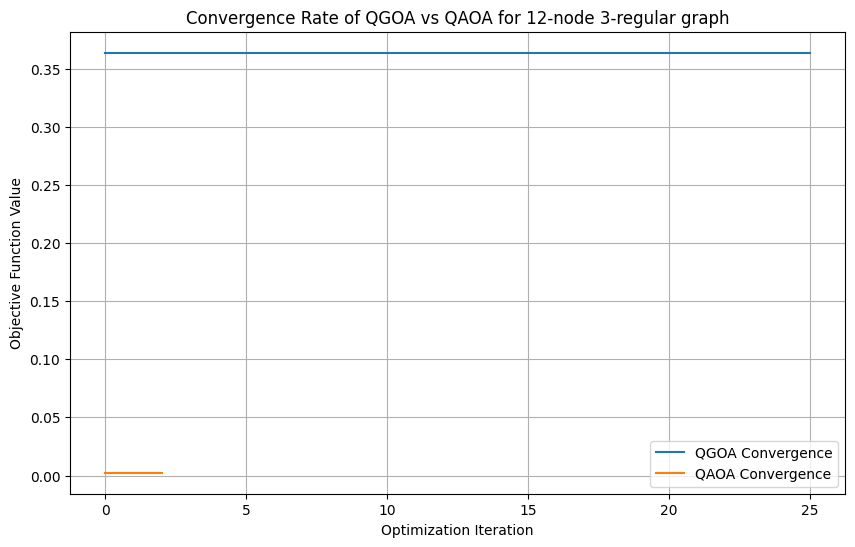

In [61]:
import time
import matplotlib.pyplot as plt

# Generate a 20-node 3-regular graph
num_nodes_for_graph = 12
try:
    test_graph = generate_3_regular_graph_sample(num_nodes_for_graph)
except ValueError as e:
    print(f"Error generating graph: {e}")
    test_graph = None

if test_graph:
    print(f"Running QGOA for a {num_nodes_for_graph}-node 3-regular graph...")
    start_time_qgoa = time.time()
    cut_value_qgoa, best_sol_bitstring_qgoa, objective_func_vals_qgoa = run_qgoa(test_graph, num_layers=1) # Using 1 layer as default for this test
    end_time_qgoa = time.time()

    elapsed_time_qgoa = end_time_qgoa - start_time_qgoa

    print(f"QGOA Max Cut Value: {cut_value_qgoa}")
    print(f"Best Solution (QGOA): {best_sol_bitstring_qgoa}")
    print(f"Time taken for QGOA on {num_nodes_for_graph}-node 3-regular graph: {elapsed_time_qgoa:.4f} seconds")

    print(f"\nRunning QAOA for a {num_nodes_for_graph}-node 3-regular graph...")
    start_time_qaoa = time.time()
    cut_value_qaoa, best_sol_bitstring_qaoa, objective_func_vals_qaoa = run_qaoa(test_graph, num_layers=1) # Using 1 layer as default for this test
    end_time_qaoa = time.time()

    elapsed_time_qaoa = end_time_qaoa - start_time_qaoa

    print(f"QAOA Max Cut Value: {cut_value_qaoa}")
    print(f"Best Solution (QAOA): {best_sol_bitstring_qaoa}")
    print(f"Time taken for QAOA on {num_nodes_for_graph}-node 3-regular graph: {elapsed_time_qaoa:.4f} seconds")

    print(f"\nTime comparison: QGOA took {elapsed_time_qgoa:.4f}s, QAOA took {elapsed_time_qaoa:.4f}s.")

    # Plotting the convergence rate
    plt.figure(figsize=(10, 6))
    plt.plot(objective_func_vals_qgoa, label='QGOA Convergence')
    plt.plot(objective_func_vals_qaoa, label='QAOA Convergence')
    plt.xlabel('Optimization Iteration')
    plt.ylabel('Objective Function Value')
    plt.title(f'Convergence Rate of QGOA vs QAOA for {num_nodes_for_graph}-node 3-regular graph')
    plt.legend()
    plt.grid(True)
    plt.show()

Calculating brute-force max cut for a 16-vertex graph...

Brute-force Max Cut Value for 16 vertices: 40.975995456235054
Corresponding partition: [0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1]
Time taken for brute-force max cut on 16-vertex graph: 5.8567 seconds

Plotting the graph with the best partition...


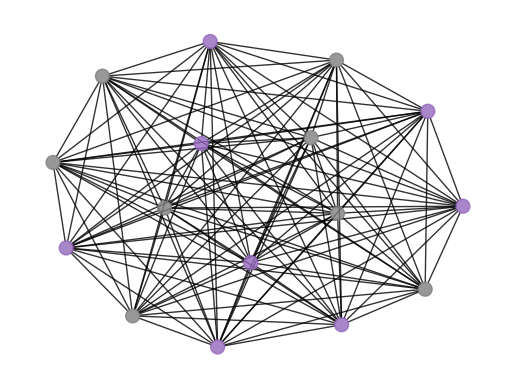

In [62]:
import time
from __main__ import generate_graph, bruteforce_max_cut, plot_result

num_nodes = 16

try:
    graph_16_vertices = generate_graph('complete', num_nodes)
except ValueError as e:
    print(f"Error generating graph: {e}")
    graph_16_vertices = None

if graph_16_vertices:
    print(f"Calculating brute-force max cut for a {num_nodes}-vertex graph...")
    start_time = time.time()
    best_cut_value, best_partition = bruteforce_max_cut(graph_16_vertices, max_nodes_limit=num_nodes)
    end_time = time.time()

    elapsed_time = end_time - start_time

    if best_cut_value is not None:
        print(f"\nBrute-force Max Cut Value for {num_nodes} vertices: {best_cut_value}")
        print(f"Corresponding partition: {best_partition}")
    else:
        print(f"\nBrute-force calculation skipped for {num_nodes} vertices (limit exceeded or error).")

    print(f"Time taken for brute-force max cut on {num_nodes}-vertex graph: {elapsed_time:.4f} seconds")

    if best_partition:
        print("\nPlotting the graph with the best partition...")
        plot_result(graph_16_vertices, best_partition)